### 2. CellPhoneDBの適用
- データセット: GSE129516
    - Landscape of intercellular crosstalk in fatty liver disease revealed by single-cell secretome analysis (Cell, 2019)
    - Mouse NASH Liver
- 内容
    - `1_preprocessing.ipynb`を実行した想定
    - オルソログを考慮したヒト遺伝子名への変換（ヒトデータを入力とする場合は不要）
    - CellPhoneDBの実行に必要な情報を取得・保存
    - CellPhoneDBの実行


In [8]:
# Prepare environment
# ! pip install ktplotspy
# ! pip install cellphonedb

***
### 各種データの準備
- ORTHOLOG_PATH: ヒトとマウスの遺伝子名を対応付けるテーブル
    - CellPhoneDBはhumanのデータのみを想定(この辺りの[issue](https://github.com/ventolab/CellphoneDB/issues/9)を参照)。
    - マウスデータを解析する場合は、orthologを考慮してhuman遺伝子名に変換する必要がある。
    - `orthologsBioMART`(https://github.com/vitkl/orthologsBioMART)を使用して変換テーブルをレポジトリに格納している。
- CPDB_PATH: 最新のデータベースをDLして指定。
    - 詳しくは[https://github.com/ventolab/cellphonedb-data](https://github.com/ventolab/cellphonedb-data)を参照。

In [ ]:
DATA_DIR = '/workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516'
ORTHOLOG_PATH = '/workspace/cluster/HDD/azuma/Azuma_ISN/github/omics-util/ccc/data/mgi_hgnc_ortholog.csv'  # in this repository
CPDB_PATH = '/workspace/cluster/HDD/azuma/Azuma_ISN/datasource/CellphoneDB_data/v5.0.0/cellphonedb_02_20_2024_110617.zip'  # DL

import pandas as pd
import anndata as ad
import ktplotspy as kpy
import matplotlib.pyplot as plt

from cellphonedb.src.core.methods import cpdb_statistical_analysis_method


***
#### 必要なデータを揃える
1. gse129516_counts_ortholog.h5ad
2. metadata.tsv
3. microenv.tsv

In [7]:
# Load processed scRNA-Seq data
adata = ad.read(f'{DATA_DIR}/processed/gse129516_manual_ann.h5ad')  # 13259 × 18514

# Convert gene names to HGNC symbol
ortholog_info = pd.read_csv(ORTHOLOG_PATH,index_col=0)
mgi2hgnc = dict(zip(ortholog_info['mgi_symbol'].tolist(), ortholog_info['hgnc_symbol'].tolist()))
adata.var["HGNC"] = [mgi2hgnc.get(t) for t in adata.var.index.tolist()]  # add HGNC gene list
adata = adata[:,adata.var["HGNC"].notna()]  # 13259 x 12894
adata.obs_names_make_unique()

# Save counts data
counts_adata = ad.AnnData(adata.layers['counts'])
counts_adata.obs_names = adata.obs.index.tolist()
counts_adata.var_names = adata.var["HGNC"].tolist()
counts_adata.obs['cell_type'] = adata.obs['manual_annotation'].tolist()
counts_adata.obs_names_make_unique()  # Note: Important to avoid error

counts_adata.write(f'{DATA_DIR}/processed/gse129516_counts_ortholog.h5ad')  # save

# Process meta info table and save
meta_df = pd.DataFrame({'barcode_sample':counts_adata.obs.index.tolist()})
meta_df['cell_type'] = counts_adata.obs['cell_type'].tolist()
meta_df.to_csv(f'{DATA_DIR}/processed/metadata.tsv',sep='\t',index=False)

# Microenvironment
me = pd.DataFrame({'cell_type':counts_adata.obs['cell_type'].unique().tolist()})
me['microenvironment'] = ['Env1']*len(me)
me.to_csv(f'{DATA_DIR}/processed/microenv.tsv',sep='\t',index=False)


***
#### CellPhoneDBの実行
- データによっては30mins程度かかることもある

Reading user files...
The following user files were loaded successfully:
/workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/gse129516_counts_ortholog.h5ad
/workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/metadata.tsv
/workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/microenv.tsv
[ ][CORE][30/09/25-17:02:47][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][30/09/25-17:02:47][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][30/09/25-17:02:50][INFO] Running Real Analysis
[ ][CORE][30/09/25-17:02:50][INFO] Limiting cluster combinations using microenvironments
[ ][CORE][30/09/25-17:02:50][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [25:20<00:00,  1.52s/it]


[ ][CORE][30/09/25-17:28:12][INFO] Building Pvalues result
[ ][CORE][30/09/25-17:28:12][INFO] Building results
[ ][CORE][30/09/25-17:28:12][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 9/9 [00:00<00:00, 40.78it/s]

[ ][CORE][30/09/25-17:28:13][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 9/9 [00:00<00:00, 100.82it/s]


[ ][CORE][30/09/25-17:28:13][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 81/81 [01:36<00:00,  1.19s/it]


Saved deconvoluted to /workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/cpdb_outputs/statistical_analysis_deconvoluted_09_30_2025_172951.txt
Saved deconvoluted_percents to /workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/cpdb_outputs/statistical_analysis_deconvoluted_percents_09_30_2025_172951.txt
Saved means to /workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/cpdb_outputs/statistical_analysis_means_09_30_2025_172951.txt
Saved pvalues to /workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/cpdb_outputs/statistical_analysis_pvalues_09_30_2025_172951.txt
Saved significant_means to /workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/cpdb_outputs/statistical_analysis_significant_means_09_30_2025_172951.txt
Saved interaction_scores to /workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516/processed/cpdb_outputs/statistical_analysis_inter

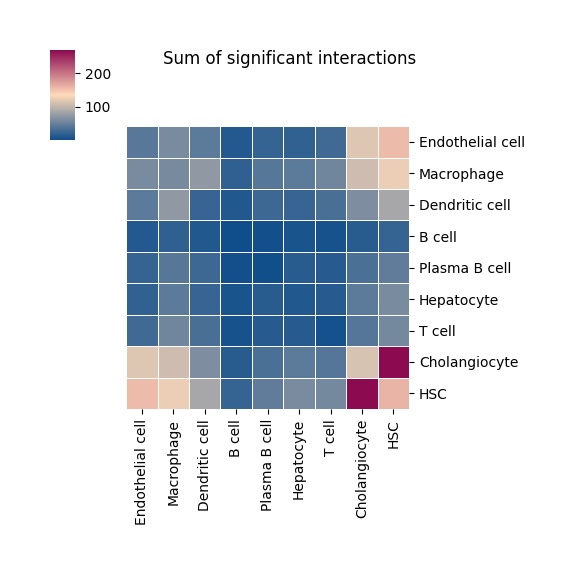

In [12]:
cpdb_file_path = CPDB_PATH
meta_file_path = f'{DATA_DIR}/processed/metadata.tsv'
counts_file_path = f'{DATA_DIR}/processed/gse129516_counts_ortholog.h5ad'
microenvs_file_path = f'{DATA_DIR}/processed/microenv.tsv'
out_path = f'{DATA_DIR}/processed/cpdb_outputs'

adata = ad.read_h5ad(counts_file_path)
metadata = pd.read_csv(meta_file_path, sep = '\t')
envdata = pd.read_csv(microenvs_file_path, sep = '\t')
list(adata.obs.index).sort() == list(metadata['barcode_sample']).sort()


cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,          # optional: defines cell types and their active TFs.
    microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

# Sum of significant interactions
kpy.plot_cpdb_heatmap(pvals = cpdb_results['pvalues'],
                      degs_analysis = False,
                      figsize = (5, 5),
                      title = "Sum of significant interactions")

***
#### 追加の解析
- cpdb_outputsの出力を用いて追加の解析を行うことも可能
- celltype1, celltype2, gene_familyなどを指定することで、詳細な相互作用情報を取得できる
- styleがバグる傾向にあるので、自前でvisualizeモジュールを用意した方が良さそう

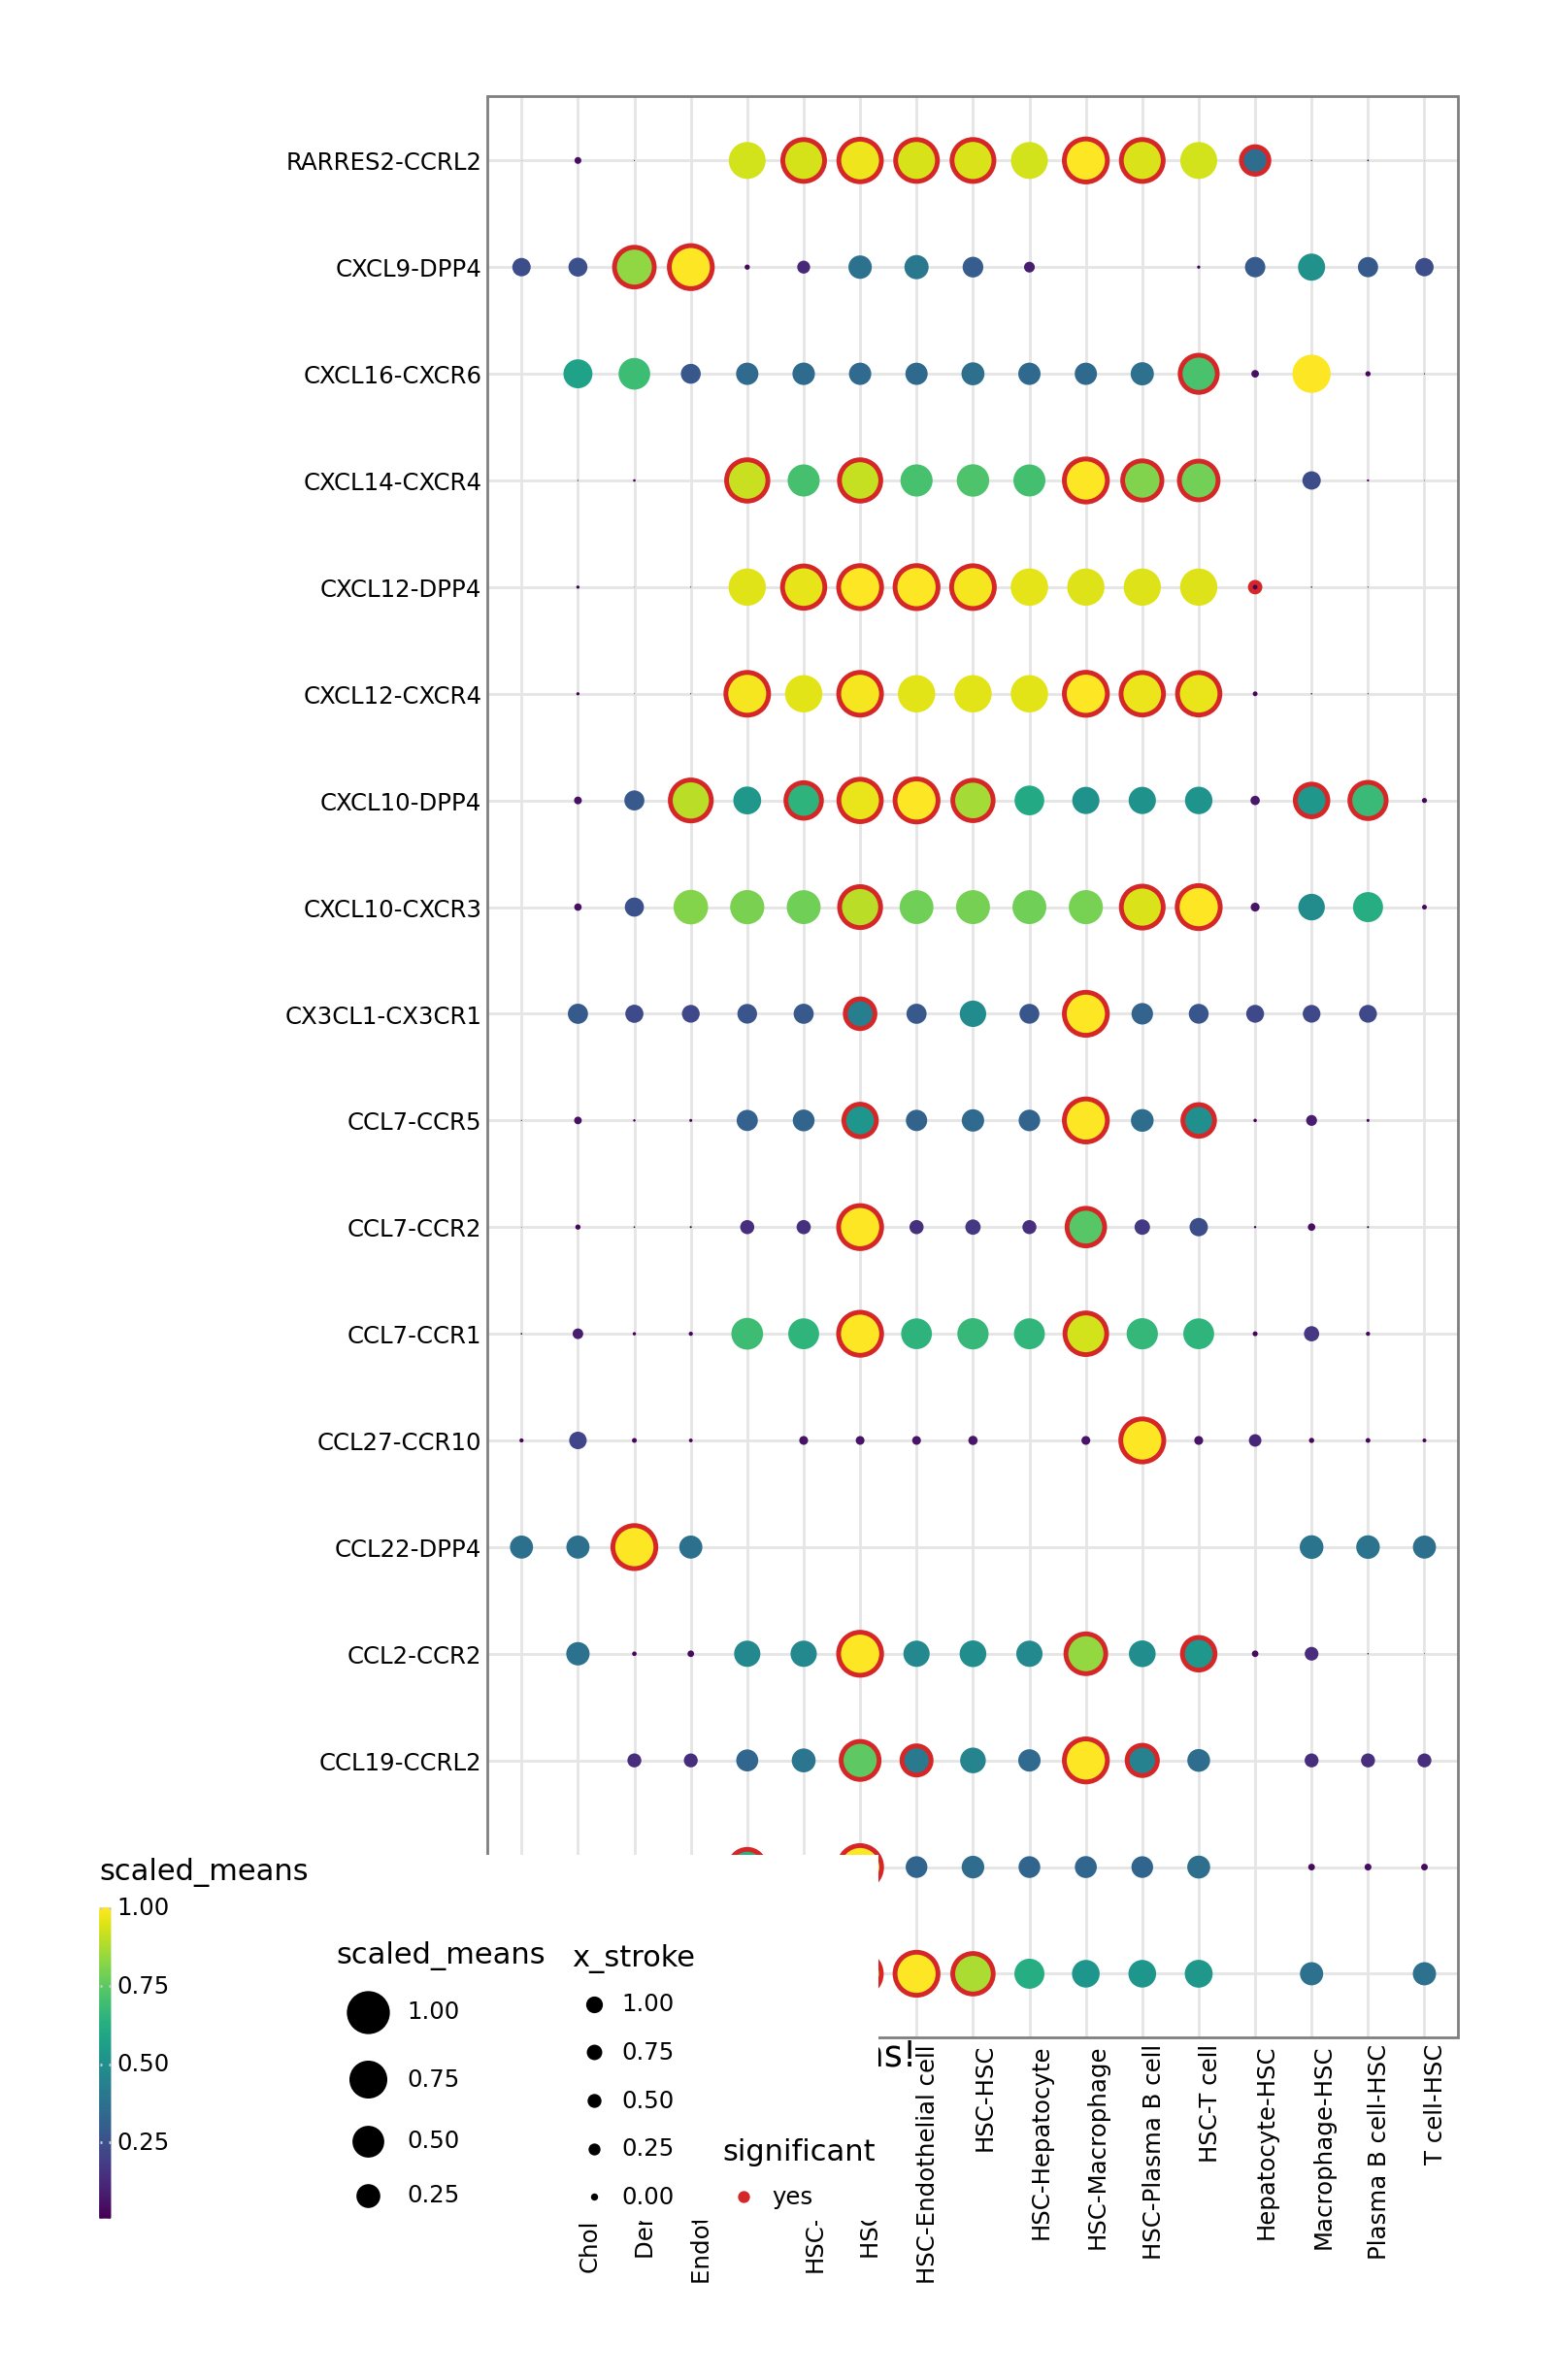

In [18]:
# Load data
adata = ad.read_h5ad(f"{DATA_DIR}/processed/gse129516_counts_ortholog.h5ad")
means = pd.read_csv(f"{DATA_DIR}/processed/cpdb_outputs/statistical_analysis_means_09_30_2025_172951.txt", sep="\t")
pvals = pd.read_csv(f"{DATA_DIR}/processed/cpdb_outputs/statistical_analysis_pvalues_09_30_2025_172951.txt", sep="\t")
decon = pd.read_csv(f"{DATA_DIR}/processed/cpdb_outputs/statistical_analysis_deconvoluted_percents_09_30_2025_172951.txt", sep="\t")

kpy.plot_cpdb(
    adata=adata,
    cell_type1="HSC",
    cell_type2=".",
    means=means,
    pvals=pvals,
    celltype_key="cell_type",
    #genes=["IL6", "IL10"],
    gene_family="chemokines",
    highlight_size=1,
    figsize=(5, 10),
    title="interacting interactions!",
    default_style=True,
    keep_id_cp_interaction=False,
)
